In [110]:
!pip install -q yfinance 
!pip install -q PyPortfolioOpt
!pip install -q xgboost
!pip install -q statsmodels arch tqdm

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

import yfinance as yf

# plotting
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.patches as mpatches
from IPython.display import display, Markdown

from typing import Tuple
from utils import ForecastingMetrics, TradingMetrics
from backtest import Backtest

import warnings

# Finance 
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import plotting
import matplotlib.pyplot as plt
import pandas as pd
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from statsmodels.tsa.api import VAR

# ml
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA

# Custom
from utils import PortfolioEvaluator
from backtest import Backtest

In [3]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]

# Define date range
start = "2022-01-01"
end = "2025-01-01"

# Download historical data
close_historical_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]
close_historical_df.head()

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMZN,BAC,C,CL,COP,COST,CVX,DIA,EOG,...,PEP,PG,QQQ,SLB,SPY,TSLA,VTI,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,178.270340,170.404495,41.931023,54.393017,76.912781,63.700043,540.298523,101.482437,341.154144,75.843277,...,154.084122,147.359802,392.184113,29.220690,453.210419,399.926666,230.069717,45.828438,45.858700,55.125244
2022-01-04,176.007767,167.522003,43.574478,54.815399,77.167381,66.463234,537.933960,103.328949,343.197205,79.329262,...,154.306824,147.875381,387.097198,30.639345,453.058655,383.196655,229.634155,47.653263,45.018562,57.198719
2022-01-05,171.326004,164.356995,42.839008,54.177517,77.485603,65.323425,524.290955,104.001213,339.670685,77.873314,...,154.832352,148.544815,375.205200,30.639345,444.358917,362.706665,224.653397,47.237709,45.627270,57.910133
2022-01-06,168.465988,163.253998,43.701599,55.953270,76.976418,67.775742,524.176697,104.886162,338.084778,79.470711,...,154.867996,147.296448,374.941589,31.367102,443.941437,354.899994,224.596588,48.448235,45.500450,59.272213
2022-01-07,168.632492,162.554001,44.654995,56.703209,76.776405,69.632240,511.191437,106.392326,338.010101,81.667137,...,155.063965,147.215073,370.879913,32.269890,442.186371,342.320007,223.573990,49.478085,45.934784,59.758034


From Figure 4, raw prices across the 30 stocks are highly variable and generally exhibit a strong upward trend. Thus, we applied a log transformation to stabilize the variance and allow for easier comparison across stocks. Additionally, since our framework relies on log returns, applying the log transformation is consistent with our methodology and ensures the returns are appropriately scaled for subsequent analysis.

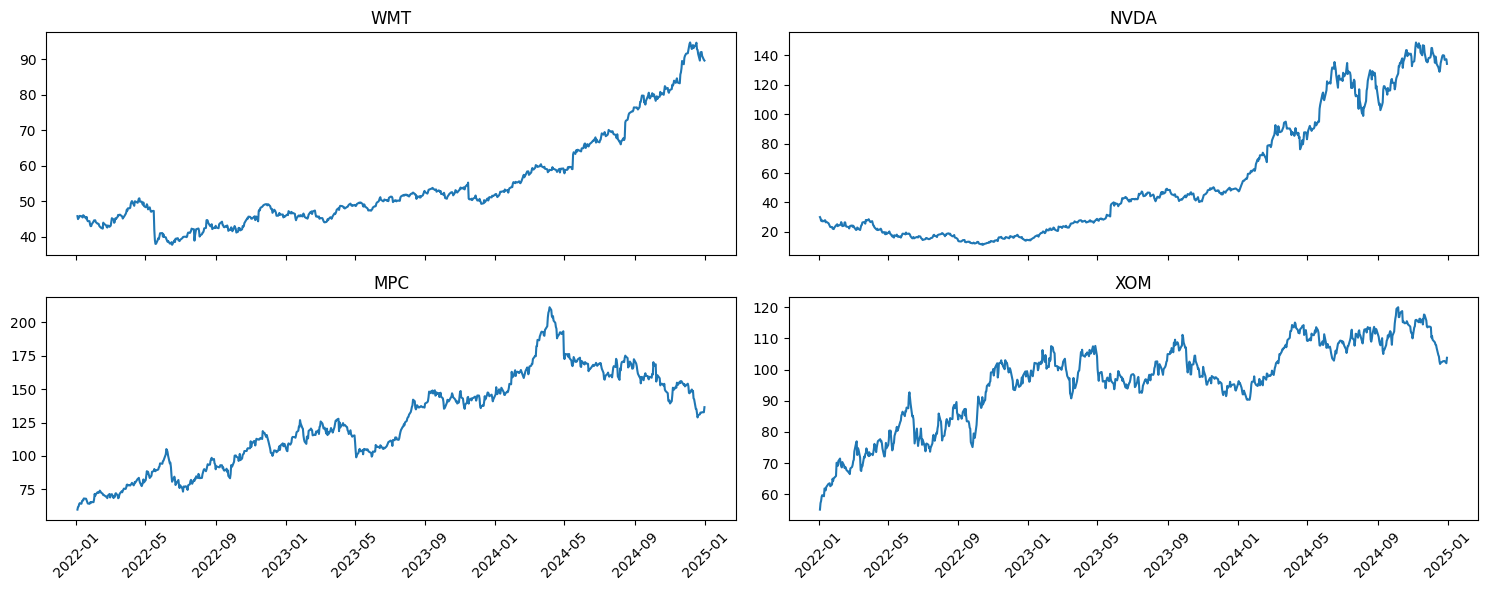

**Figure 4.** USD Prices of the 4 Stocks

In [5]:
selected_stocks = ["WMT", "NVDA", "MPC", "XOM"]
close_historical_df = close_historical_df[selected_stocks]

fig, axs = plt.subplots(2, 2, figsize=(15, 6), sharex=True)

for ax, stock in zip(axs.flatten(), close_historical_df.columns):
    ax.plot(close_historical_df[stock])
    ax.set_title(stock)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

display(Markdown("**Figure 4.** USD Prices of the 4 Stocks"))

In [6]:
# Keep only the stocks with non-zero weights
selected_stocks = ["WMT", "NVDA", "MPC", "XOM"]
close_historical_df = close_historical_df[selected_stocks]

# Baselines

To construct the baseline models (mean, naive, and seasonal naive) in a single figure, we first assessed whether seasonality was present across the stocks. As shown in Figure 5, there is no consistent or systematic seasonal pattern observable across the full set of assets. Given this inconsistency, we proceed by assuming a simplified seasonality of 20 business days (a month) for the baseline seasonal naive model.

We also implement a three-way data split into training, validation, and test sets, covering the period from January 2022 to January 2025, using a 70–20–10 split. For modeling purposes, we predict log prices, as our framework relies on PyPortfolioOpt functions such as `mean_historical_return` and `CovarianceShrinkage`, which require the actual price data. Therefore, after generating the log price forecasts, we can simply exponentiate the results to recover the prices in their original scale.

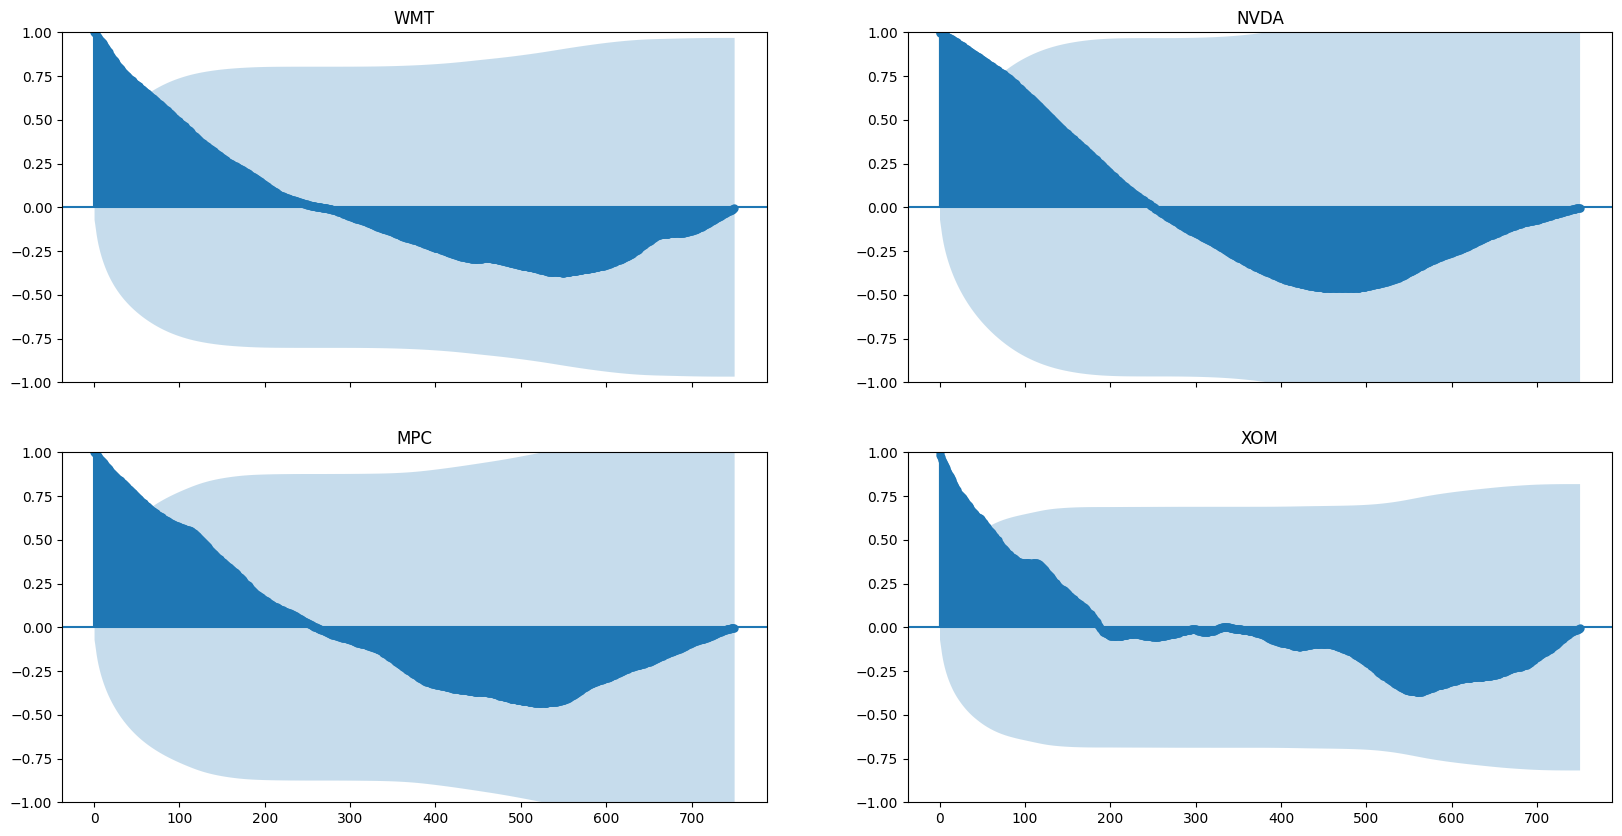

**Figure 5.** ACF of the 4 Stocks

In [7]:
# Apply log
close_log_df = np.log(close_historical_df)

fig, axs = plt.subplots(2, 2, figsize=(20, 10), sharex=True)

for ax, stock in zip(axs.flatten(), close_log_df.columns):
    plot_acf(close_log_df[stock], ax=ax, lags=750, title=stock)

plt.show()

display(Markdown("**Figure 5.** ACF of the 4 Stocks"))

In [8]:
# Total number of rows
n = close_log_df.shape[0]

# Compute split points
train_end = int(n * 0.7)           # 70% for training
val_end = train_end + int(n * 0.2) # next 20% for validation

# Create splits
train_df = close_log_df.iloc[:train_end]
val_df = close_log_df.iloc[train_end:val_end]
test_df = close_log_df.iloc[val_end:]

print(f"Training set: {train_df.shape[0]} rows ({train_df.shape[0]/n:.0%})")
print(f"Validation set: {val_df.shape[0]} rows ({val_df.shape[0]/n:.0%})")
print(f"Test set: {test_df.shape[0]} rows ({test_df.shape[0]/n:.0%})")


Training set: 527 rows (70%)
Validation set: 150 rows (20%)
Test set: 76 rows (10%)


In [9]:
def forecast_seasonal_naive(df: pd.DataFrame, m: int = 5, horizon: int = None) -> pd.DataFrame:
    """
    Seasonal naïve forecasting model applied column-wise to a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame where each column represents a univariate time series
        (e.g., multiple stock price series).
    m : int, optional (default=5)
        The assumed seasonality length. The model uses the last `m` observations
        of each column as the repeating seasonal pattern.
    horizon : int, optional
        Number of future time steps to forecast. If None, uses length of df.

    Returns
    -------
    pd.DataFrame
        A DataFrame containing seasonal naïve forecasts for each column of `df`.
        Each column contains `horizon` forecasts derived from the last `m` values.
    """
    if horizon is None:
        horizon = len(df)

    forecasts = {}
    for col in df.columns:
        last_m_vals = df[col].iloc[-m:].values.ravel()
        repeated_vals = np.tile(last_m_vals, horizon)[:horizon]
        forecasts[col] = repeated_vals

    return pd.DataFrame(forecasts)


In [10]:
horizon = val_df.shape[0]  # number of rows to forecast

# Mean forecast
mean_forecast = pd.DataFrame([train_df.mean().values] * horizon,
                             index=val_df.index,
                             columns=val_df.columns)

# Naive forecast (last value)
naive_forecast = pd.DataFrame([train_df.iloc[-1].values] * horizon,
                              index=val_df.index,
                              columns=val_df.columns)

# Seasonal naive forecast
seasonal_naive_forecast = forecast_seasonal_naive(train_df, m=20, horizon=horizon)
seasonal_naive_forecast.index = val_df.index


From Figure 6, we plotted all four stocks with reduced opacity and highlighted the mean to facilitate easier visualization. Among the three baseline models, the naive forecast performs best on the validation set, capturing the general movement of the log prices more accurately than the mean or seasonal naive forecasts.

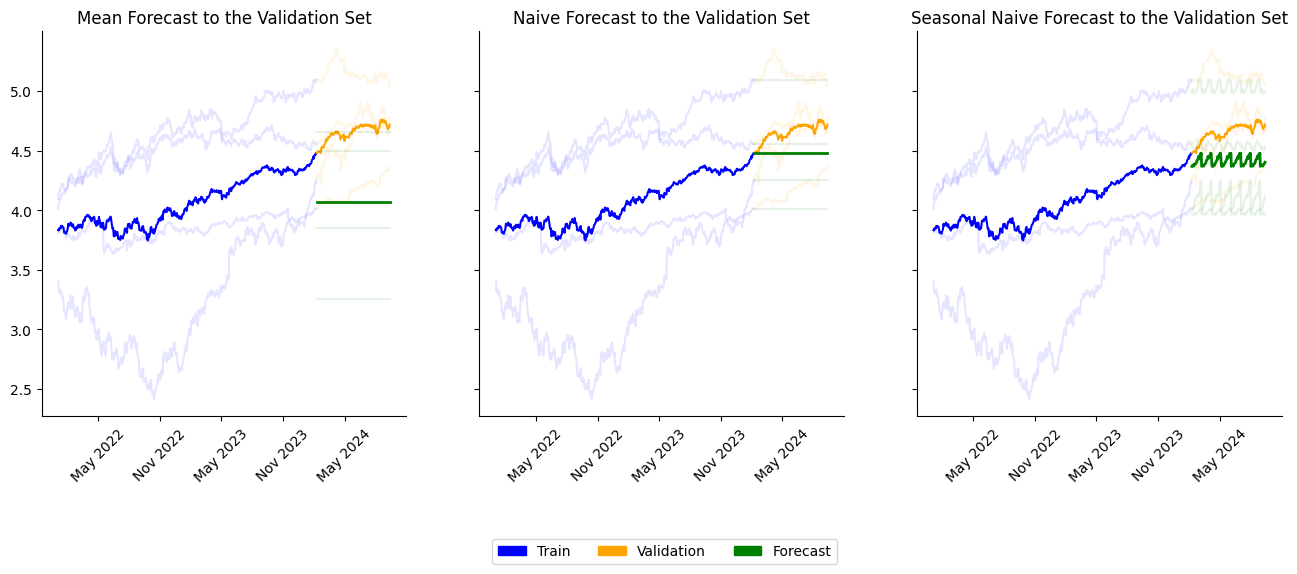

**Figure 6.** Baseline Forecasts of Log Prices Across Stocks

In [11]:

# Drawing time!
fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

opacity_num = 0.1
for ax in axs:
    ax.plot(train_df, color='blue', alpha=opacity_num)
    ax.plot(train_df.mean(axis=1), color='blue')

    ax.plot(val_df, color='orange', alpha=opacity_num)
    ax.plot(val_df.mean(axis=1), color='orange', label='Val Median')

# Plot the mean
axs[0].plot(mean_forecast, label='Mean Forecast', color='green', alpha=opacity_num)
axs[0].plot(mean_forecast.mean(axis=1), label='Mean Forecast', linewidth=2, color='green')
axs[0].set_title('Mean Forecast to the Validation Set')

# plot the naive
axs[1].plot(naive_forecast, label='Naive Forecast', color='green', alpha=opacity_num)
axs[1].plot(naive_forecast.mean(axis=1), label='Naive Forecast', linewidth=2, color='green')
axs[1].set_title('Naive Forecast to the Validation Set')

# plot the Seasonal Naive
axs[2].plot(seasonal_naive_forecast, label='Seasonal Naive Forecast', color='green', alpha=opacity_num)
axs[2].plot(seasonal_naive_forecast.mean(axis=1), label='Seasonal Naive Forecast', linewidth=2, color='green')
axs[2].set_title('Seasonal Naive Forecast to the Validation Set')

# Prettier x-axis
for ax in axs:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # major ticks each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format as 'Jan 2025'
    ax.tick_params(axis='x', rotation=45)  # rotate labels
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', bbox_to_anchor=(-0.2, -0.3), ncol=3)

plt.show()

display(Markdown("**Figure 6.** Baseline Forecasts of Log Prices Across Stocks"))


In [12]:
# Dictionary to store all metrics
performance_stock = {}

for stock in val_df.columns:
    # Compute metrics for each baseline
    performance_stock[stock] = {
        'Mean': ForecastingMetrics.compute_all_metrics(val_df[stock], mean_forecast[stock]),
        'Naive': ForecastingMetrics.compute_all_metrics(val_df[stock], naive_forecast[stock]),
        'Seasonal Naive': ForecastingMetrics.compute_all_metrics(val_df[stock], seasonal_naive_forecast[stock])
    }

In [13]:
def performance_dict_to_df(performance_stock_dict):
    """
    Converts a nested dictionary of performance metrics into a multi-index DataFrame.
    
    Parameters
    ----------
    performance_stock_dict : dict
        Nested dict of the form {stock: {model_name: {metric_name: value, ...}, ...}, ...}
    
    Returns
    -------
    pd.DataFrame
        MultiIndex DataFrame with index ['Stock', 'Model'] and metric columns.
    """
    df_list = []

    for stock, metrics_per_model in performance_stock_dict.items():
        for model, metrics in metrics_per_model.items():
            row = metrics.copy()
            row['Stock'] = stock
            row['Model'] = model
            df_list.append(row)
    
    metrics_df = pd.DataFrame(df_list).set_index(['Stock', 'Model'])
    return metrics_df

#performance_dict_to_df(performance_stock)


# ARIMA


The first step in constructing an ARIMA model is to assess the stationarity of the log price time series using the Augmented Dickey-Fuller (ADF) and Kwiatkowski-Phillips-Schmidt-Shin (KPSS) tests. We applied both tests across all stocks, recording the results in Table 3. For the four stocks, none of them passed both tests, so they were considered non-stationary and were thus differenced to get the stock's log returns.

In [14]:
warnings.filterwarnings("ignore")

# --- ADF Test Function ---
def adf_test_suite(timeseries):
    """
    Performs the Augmented Dickey-Fuller test on a time series.
    H0: The series is non-stationary.
    """
    # Use 'ct' for constant and trend since visual inspection (Figure 2) shows a clear trend
    result = adfuller(timeseries, autolag='AIC', regression='ct')
    
    p_value = result[1]
    
    # Check p-value against a 5% significance level (alpha=0.05)
    is_stationary = 'Stationary' if p_value <= 0.05 else 'Non-Stationary'
    
    return pd.Series({
        'ADF Statistic': result[0],
        'ADF P-value': p_value,
        'ADF Lags Used': result[2],
        'ADF Conclusion (alpha=0.05)': is_stationary
    })

# --- KPSS Test Function ---
def kpss_test_suite(timeseries):
    """
    Performs the Kwiatkowski-Phillips-Schmidt-Shin test on a time series.
    H0: The series is trend-stationary.
    """
    # Use 'ct' for trend-stationarity (constant and trend)
    result = kpss(timeseries, regression='ct', nlags='auto')
    
    p_value = result[1]
    
    # Check p-value against a 5% significance level (alpha=0.05)
    is_stationary = 'Stationary' if p_value > 0.05 else 'Non-Stationary'
    
    return pd.Series({
        'KPSS Statistic': result[0],
        'KPSS P-value': p_value,
        'KPSS Lags Used': result[2],
        'KPSS Conclusion (alpha=0.05)': is_stationary
    })

In [15]:
adf_results_df = close_log_df.apply(adf_test_suite, axis=0).T
kpss_results_df = close_log_df.apply(kpss_test_suite, axis=0).T

final_results = pd.DataFrame({
    'ADF Conclusion': adf_results_df['ADF Conclusion (alpha=0.05)'],
    'KPSS Conclusion': kpss_results_df['KPSS Conclusion (alpha=0.05)']
})

def consolidate_conclusion(row):
    """Consolidate stationarity conclusions from ADF and KPSS tests for a time series."""
    adf_c = row['ADF Conclusion']
    kpss_c = row['KPSS Conclusion']
    
    if adf_c == 'Stationary' and kpss_c == 'Stationary':
        return 'Strictly Stationary (Strong Evidence)'
    elif adf_c == 'Non-Stationary' and kpss_c == 'Non-Stationary':
        return 'Non-Stationary (Strong Evidence)'
    elif adf_c == 'Stationary' and kpss_c == 'Non-Stationary':
        # ADF rejects Unit Root, KPSS rejects Trend-Stationary. Contradictory.
        # Often implies the series is difference stationary (needs differencing).
        return 'Difference Stationary (Requires Differencing)'
    elif adf_c == 'Non-Stationary' and kpss_c == 'Stationary':
        # ADF fails to reject Unit Root, KPSS fails to reject Trend-Stationary.
        # Often implies the series is trend stationary (needs detrending).
        return 'Trend Stationary (Requires Detrending)'
    else:
        return 'Inconclusive/Contradictory'

final_results['Consolidated Conclusion'] = final_results.apply(consolidate_conclusion, axis=1)
display(final_results)

display(Markdown("**Table 3.** ADF and KPSS Conclusions on the Log Prices"))


,ADF Conclusion,KPSS Conclusion,Consolidated Conclusion
Ticker,,,
WMT,Non-Stationary,Non-Stationary,Non-Stationary (Strong Evidence)
NVDA,Non-Stationary,Non-Stationary,Non-Stationary (Strong Evidence)
MPC,Non-Stationary,Non-Stationary,Non-Stationary (Strong Evidence)
XOM,Stationary,Non-Stationary,Difference Stationary (Requires Differencing)


**Table 3.** ADF and KPSS Conclusions on the Log Prices

As shown in Table 4, all series are stationary according to the ADF test. However, NVDA may still require differencing, as the KPSS test indicates non-stationarity. To confirm, we can first examine NVDA’s log returns visually to assess whether the series exhibits stationarity.

In [17]:
# Difference only once
close_log_df1 = close_log_df.diff().dropna()

adf_results_df = close_log_df1.apply(adf_test_suite, axis=0).T
kpss_results_df = close_log_df1.apply(kpss_test_suite, axis=0).T

final_results = pd.DataFrame({
    'ADF Conclusion': adf_results_df['ADF Conclusion (alpha=0.05)'],
    'KPSS Conclusion': kpss_results_df['KPSS Conclusion (alpha=0.05)']
})

final_results['Consolidated Conclusion'] = final_results.apply(consolidate_conclusion, axis=1)
display(final_results)

display(Markdown("**Table 4.** ADF and KPSS Conclusions on the Log Returns"))

,ADF Conclusion,KPSS Conclusion,Consolidated Conclusion
Ticker,,,
WMT,Stationary,Stationary,Strictly Stationary (Strong Evidence)
NVDA,Stationary,Non-Stationary,Difference Stationary (Requires Differencing)
MPC,Stationary,Stationary,Strictly Stationary (Strong Evidence)
XOM,Stationary,Stationary,Strictly Stationary (Strong Evidence)


**Table 4.** ADF and KPSS Conclusions on the Log Returns

Figure 7 indicates that the first-order differences of the log prices already exhibit stationarity. Additionally, financial theory, particularly within the context of Modern Portfolio Theory (MPT), supports the use of log returns (i.e., the first difference of log prices) for modeling, while further differencing may introduce unnecessary noise. Therefore, the optimal order of differencing $d$ is set to 1.

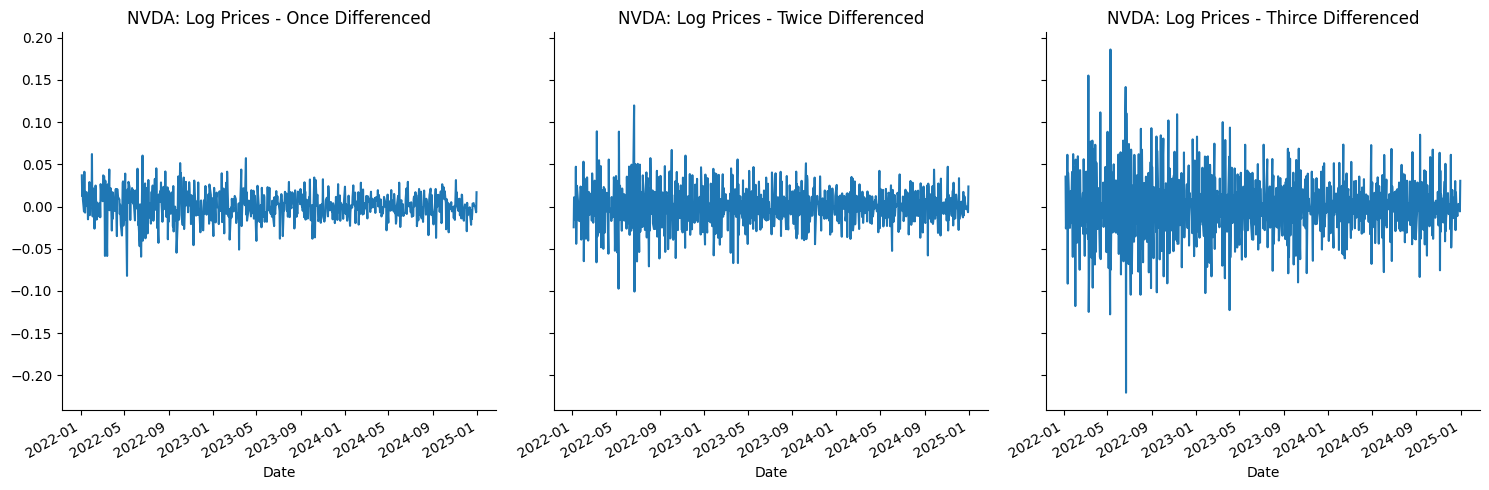

**Figure 7.** Differencing of NVDA Log Prices

In [75]:
# Plot the differenced series
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
focused_stock = 'NVDA'

# Original log returns
close_log_df1[stock].plot(ax=axes[0], title=f'{focused_stock}: Log Prices - Once Differenced')
# 2nd difference
close_log_df1[stock].diff().plot(ax=axes[1], title=f'{focused_stock}: Log Prices - Twice Differenced')
# 3rd difference
close_log_df1[stock].diff().diff().plot(ax=axes[2], title=f'{focused_stock}: Log Prices - Thirce Differenced')

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
plt.tight_layout()
plt.show()

display(Markdown("**Figure 7.** Differencing of NVDA Log Prices"))

From Figure 8, all stocks exhibit minimal autocorrelation after first-order differencing, indicating that past values do not significantly predict future values. Consequently, the optimal autoregressive order $p$ is set to 0.

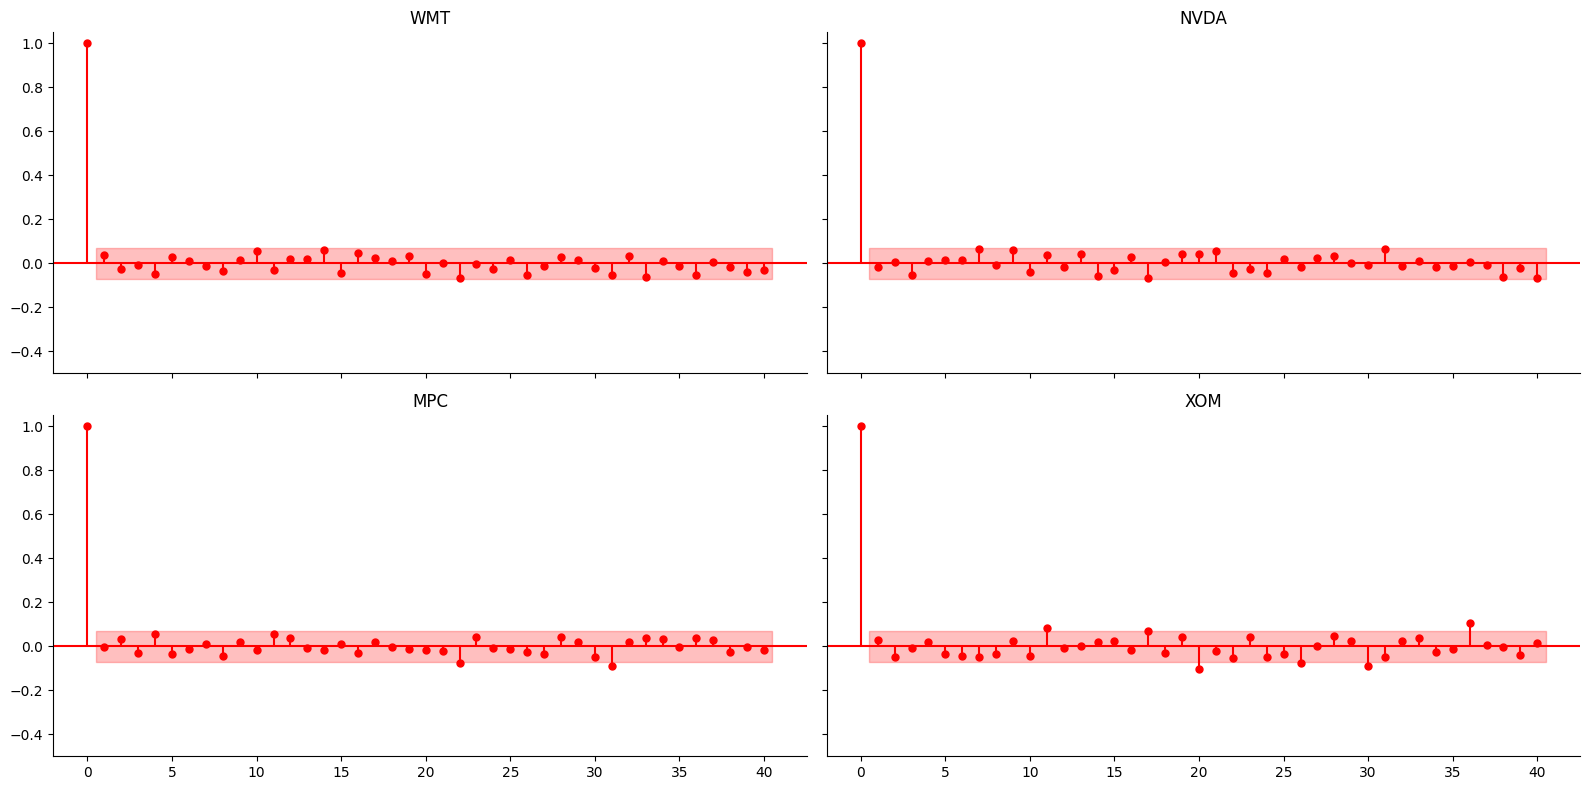

**Figure 8.** PACF of the Differenced Log Prices Across the Four Stocks

In [76]:
# Assuming close_log_df1 is your differenced data
fig, axs = plt.subplots(2, 2, figsize=(16, 8), sharex=True, sharey=True)

for ax, stock in zip(axs.flatten(), close_log_df1.columns):
    # Plot PACF
    plot_pacf(close_log_df1[stock].dropna(), ax=ax, lags=40, method='ywm')
    ax.set_title(stock)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(-0.5, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for item in ax.collections:
        item.set_color('red')
    for item in ax.lines:
        item.set_color('red')


# Add main title
#fig.suptitle('PACF of the Differenced 30 Stocks', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

display(Markdown("**Figure 8.** PACF of the Differenced Log Prices Across the Four Stocks"))

As shown in Figure 9, most stocks exhibit minimal autocorrelation after first-order differencing, suggesting limited moving average effects. Consequently, the optimal moving average order $q$ is set to 0.

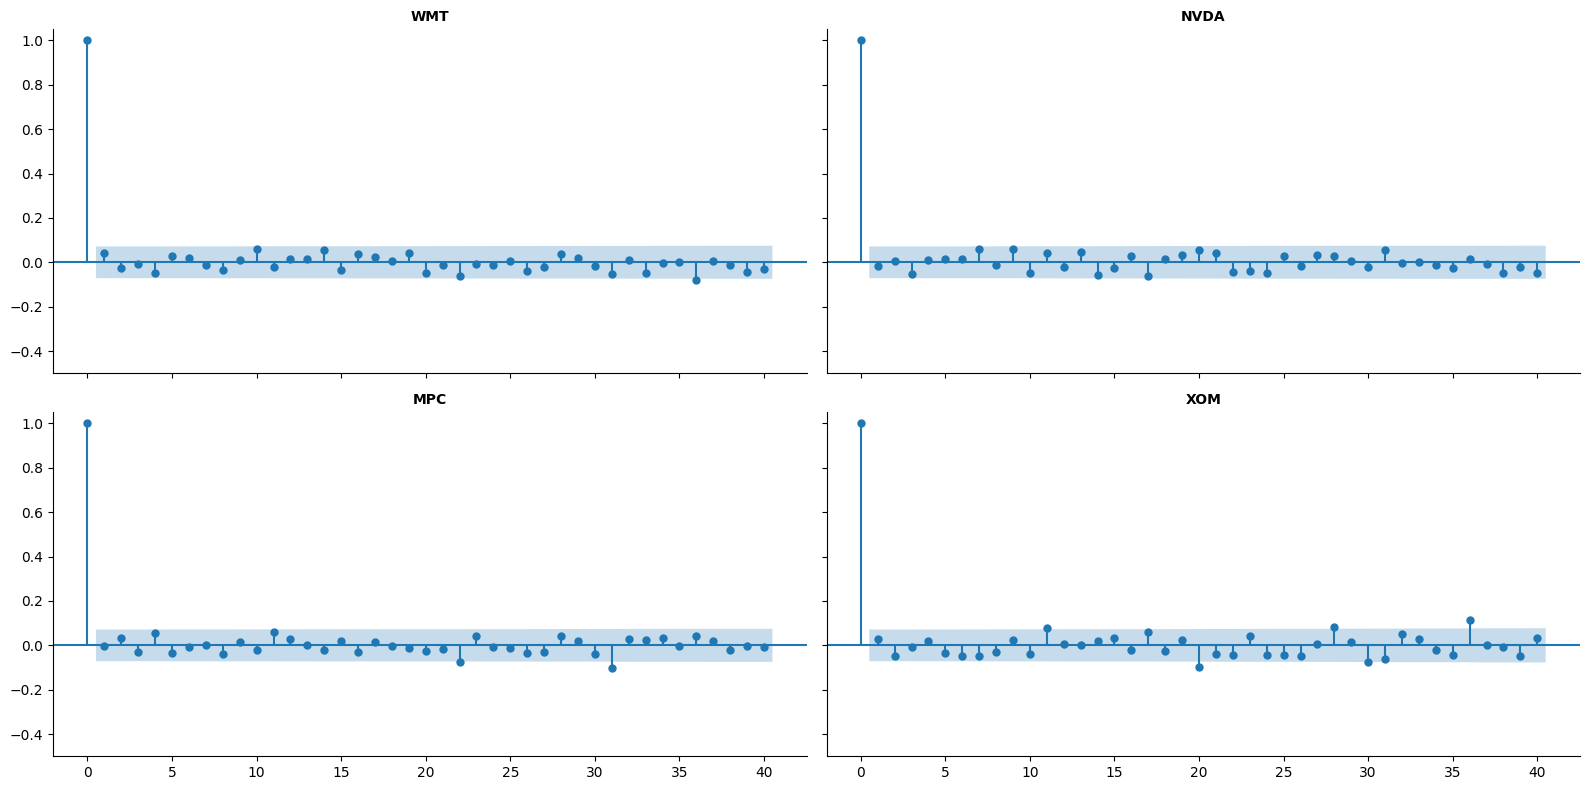

**Figure 9.** ACF of the Differenced Log Prices Across the Four Stocks

In [81]:
# Assuming close_log_df1 is your differenced data
fig, axs = plt.subplots(2, 2, figsize=(16, 8), sharex=True, sharey=True)

for ax, stock in zip(axs.flatten(), close_log_df1.columns):
    # Plot ACF
    plot_acf(close_log_df1[stock].dropna(), ax=ax, lags=40)
    ax.set_title(stock, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(-0.5, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Add main title
#fig.suptitle('ACF of the Differenced 4 Stocks', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


display(Markdown("**Figure 9.** ACF of the Differenced Log Prices Across the Four Stocks"))

As a sanity check, we evaluated all combinations of $p$ and $q$ from 0 to 4 while keeping $d = 1$ fixed. Using the Bayesian Information Criterion (BIC) as the model selection metric, we identified the optimal $(p, q)$ pair for each stock, where lower BIC values indicate a better fit. This additional validation step confirmed our earlier findings that the simplest specification, ARIMA(0, 1, 0), consistently performed best across the four stocks. This reinforces the conclusion that a random-walk structure with no autoregressive or moving-average components is the most appropriate model for these log price series.

In [18]:
# Store results for all stocks
all_results = []

# Test different orders for each stock
for stock in close_log_df.columns:
    results = {}
    
    for p in range(0, 4):
        for q in range(0, 4):
            try:
                model = ARIMA(close_log_df[stock], order=(p, 1, q))
                fitted = model.fit()
                results[(p, q)] = fitted.bic
            except Exception as e:
                # Skip models that fail to converge
                continue
    
    # Check if any models succeeded
    if len(results) > 0:
        best_model = min(results, key=results.get)
        all_results.append({
            'Stock': stock,
            'Optimal p': best_model[0],
            'Optimal q': best_model[1],
            'BIC': results[best_model]
        })
    else:
        all_results.append({
            'Stock': stock,
            'Optimal p': None,
            'Optimal q': None,
            'BIC': None
        })




In [19]:
# Create and display DataFrame
bic_results_df = pd.DataFrame(all_results)

display(bic_results_df)
display(Markdown("**Table 5:** Optimal ARIMA Orders by BIC:"))

,Stock,Optimal p,Optimal q,BIC
0,WMT,0,0,-4377.634586
1,NVDA,0,0,-2924.492866
2,MPC,0,0,-3717.605263
3,XOM,0,0,-3972.429444


**Table 5:** Optimal ARIMA Orders by BIC:

Genuinely, idk  what this plot is for huhuhu. I'm gonna comment this out. - JF

In [104]:
# # Create subplots for all 30 stocks
# fig, axs = plt.subplots(2, 2, figsize=(25, 20))

# for ax, (_, row) in zip(axs.flatten(), bic_results_df.iterrows()):
#     stock = row['Stock']
#     p = int(row['Optimal p'])
#     q = int(row['Optimal q'])
    
#     try:
#         # Get the original log prices (before differencing)
#         original_data = close_historical_df[stock].dropna()
#         log_data = np.log(original_data)
        
#         # Fit ARIMA model with d=1 (since we need to difference)
#         model = ARIMA(log_data, order=(p, 1, q))
#         fitted_model = model.fit()
        
#         # Get fitted values (in log scale)
#         fitted_log = fitted_model.fittedvalues
        
#         # Convert back to original price scale
#         fitted_prices = np.exp(fitted_log)
        
#         # Plot actual vs fitted in original price scale
#         ax.plot(original_data.index, original_data.values, 
#                 label='Actual', color='blue', alpha=0.7, linewidth=1)
#         ax.plot(fitted_prices.index, fitted_prices.values, 
#                 label='Fitted', color='red', alpha=0.7, linewidth=1)
        
#         ax.set_title(f'{stock} - ARIMA({p},1,{q})', fontsize=10, fontweight='bold')
#         ax.legend(fontsize=7, loc='best')
#         ax.grid(True, alpha=0.3)
#         ax.tick_params(axis='both', labelsize=7)
#         ax.set_ylabel('Price ($)', fontsize=8)
        
#     except Exception as e:
#         ax.text(0.5, 0.5, f'{stock}\nModel failed\n{str(e)[:30]}', 
#                 ha='center', va='center', transform=ax.transAxes, fontsize=8)
#         ax.set_title(f'{stock}', fontsize=10, fontweight='bold')

# fig.suptitle('ARIMA Model Fit: Actual vs Fitted Prices (Original Scale)', 
#              fontsize=16, fontweight='bold', y=0.995)
# plt.tight_layout()
# plt.show()

# print("Figure: ARIMA model fitted values vs actual prices (non-differenced)")

We then plotted out in Figure 10 on how ARIMA(0, 1, 0) would actually forecast the log prices, and it forecasted exactly like the naive baseline. In particular, it forecasts future log prices as

$$
\ln P_{t} = \ln P_{t-1} + \varepsilon_{t},
$$

where $\varepsilon_{t+1}$ is a white noise term with mean zero. This means that the best point forecast for the next period is simply yesterday’s log price, which is similar to the approach with the naive baseline where it just uses the latest possible log price.


In [20]:
def train_and_forecast_arima(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    bic_results_df: pd.DataFrame,
    horizon: int = None
) -> pd.DataFrame:
    """
    Train ARIMA(p,1,q) models using optimal p and q, then forecast the next horizon steps.
    """

    import warnings
    warnings.filterwarnings("ignore")

    if horizon is None:
        horizon = len(val_df)  # default to validation length

    # Ensure Stock is index
    bic_results_df = bic_results_df.set_index("Stock")

    # Prepare forecast container — same index as validation set
    arima_forecasts = pd.DataFrame(index=val_df.index, columns=val_df.columns)

    # Iterate through each stock
    for stock in train_df.columns:

        # Check if stock has BIC results
        if stock not in bic_results_df.index:
            print(f"Warning: No optimal orders found for {stock}. Skipping.")
            arima_forecasts[stock] = np.nan
            continue

        try:
            # Extract optimal p, q (ensure INT)
            p = int(bic_results_df.loc[stock, "Optimal p"])
            q = int(bic_results_df.loc[stock, "Optimal q"])
            order = (p, 1, q)

            # Fit ARIMA
            model = ARIMA(train_df[stock], order=order).fit()

            # Generate forecast
            forecast_obj = model.get_forecast(steps=horizon)
            forecast = forecast_obj.predicted_mean

            # Align forecast index to validation index
            forecast.index = val_df.index

            # Store
            arima_forecasts[stock] = forecast

        except Exception as e:
            print(f"Error fitting/forecasting ARIMA for {stock}: {e}")
            arima_forecasts[stock] = np.nan

    return arima_forecasts


In [21]:
arima_forecasts_df = train_and_forecast_arima(
    train_df, 
    val_df, 
    bic_results_df, 
    horizon=val_df.shape[0]
)


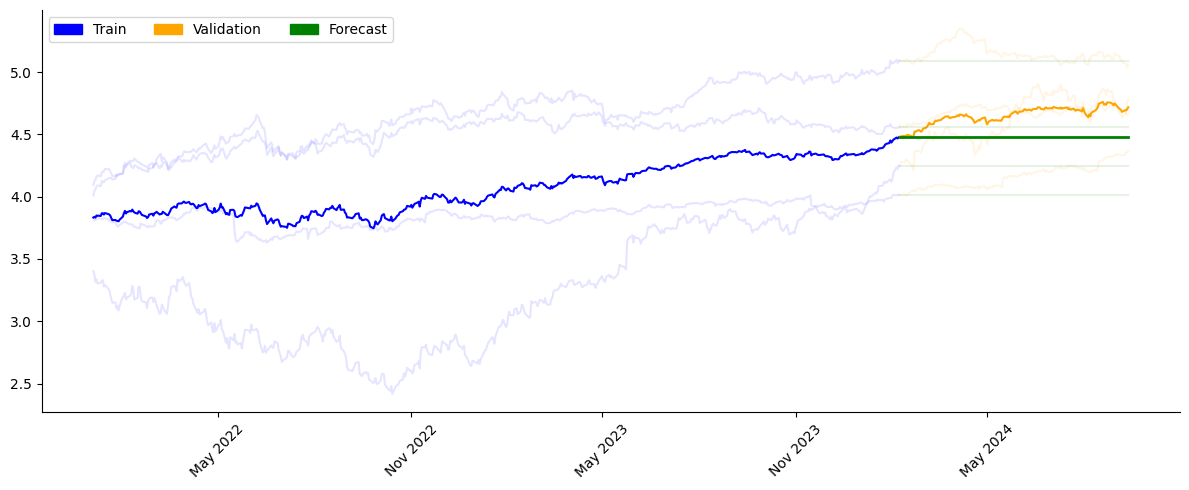

**Figure 10.** ARIMA Forecasts of Log Prices Across Stocks

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))

opacity_num = 0.1

# --- Training data ---
ax.plot(train_df, color='blue', alpha=opacity_num)
ax.plot(train_df.mean(axis=1), color='blue')

# --- Validation data ---
ax.plot(val_df, color='orange', alpha=opacity_num)
ax.plot(val_df.mean(axis=1), color='orange')

# --- ARIMA forecast ---
ax.plot(arima_forecasts_df, color='green', alpha=opacity_num, label='ARIMA Forecast')
ax.plot(arima_forecasts_df.mean(axis=1), color='green', linewidth=2, label='ARIMA Forecast Mean')

#ax.set_title('ARIMA Forecast to the Validation Set')

# Prettier x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', ncol=3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

display(Markdown("**Figure 10.** ARIMA Forecasts of Log Prices Across Stocks"))

# Random Walk with Drift

Let us now extend the random walk to include a drift. Assuming there is an underlying growth in stock prices, we take the first difference of the log prices and compute the mean. This yields the mean log return ($\mu$), which can be interpreted as the drift term in the model. We write this down as:
$$\ln P_{t} = \ln P_{t-1} + \mu + \varepsilon_{t}.$$
As shown in Figure 11, this approach better captures the log prices since it follows the upward trend of the stocks.

In [28]:
# Example: train_df is log prices, columns = stocks, rows = dates
forecast_horizon = 150

# 1. Compute mean log return (drift) per stock
drift = train_df.diff().mean(axis=0)  # pandas Series, index = stocks

# 2. Get last log price per stock
last_log_price = train_df.iloc[-1]   # Series, index = stocks

# 3. Create random walk with drift
# For simplicity, here we just add the drift deterministically (no noise)
forecast_log_prices = pd.DataFrame(
    index=val_df.index, 
    columns=train_df.columns,
    dtype=float
)

for stock in train_df.columns:
    # Add drift cumulatively
    forecast_log_prices[stock] = last_log_price[stock] + np.cumsum(np.repeat(drift[stock], forecast_horizon))

# Get the performance
for stock in selected_stocks:
    performance_stock[stock]['Random Wak with Drift'] = ForecastingMetrics.compute_all_metrics(
        val_df[stock], forecast_log_prices[stock]
    )

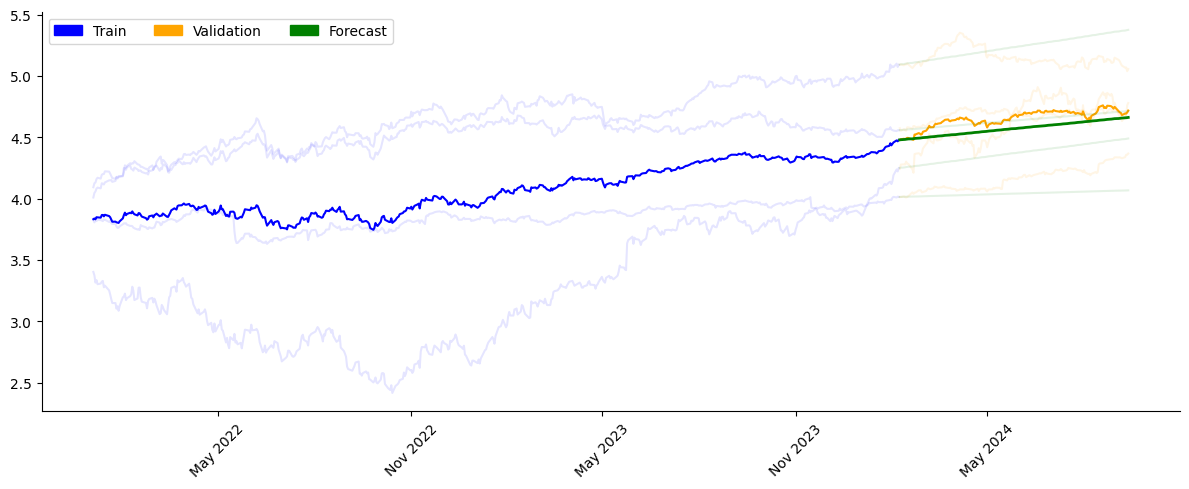

**Figure 11.** Random Walk with Drift Forecasts of Log Prices Across Stocks

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))

opacity_num = 0.1

# --- Training data ---
ax.plot(train_df, color='blue', alpha=opacity_num)
ax.plot(train_df.mean(axis=1), color='blue')

# --- Validation data ---
ax.plot(val_df, color='orange', alpha=opacity_num)
ax.plot(val_df.mean(axis=1), color='orange')

# --- ARIMA forecast ---
ax.plot(forecast_log_prices, color='green', alpha=opacity_num, label='ARIMA Forecast')
ax.plot(forecast_log_prices.mean(axis=1), color='green', linewidth=2, label='ARIMA Forecast Mean')

#ax.set_title('Random Walk with Drift Forecast to the Validation Set')

# Prettier x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', ncol=3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

display(Markdown("**Figure 11.** Random Walk with Drift Forecasts of Log Prices Across Stocks"))

# Apply ML Models

In addition to the current models we have, we also included standard machine learning models such as Random Forest, XGBoost, Linear Regression, Ridge Regression, and Gradient Boosting. Linear regression was used as a simple, interpretable benchmark for predicting linear relationships between the predictors and returns. Ridge regression extends this by adding regularization to reduce overfitting if features are correlated. Random Forest was selected as its ensemble structure captures nonlinear relationship effects between variables to make it robust to noise and overfitting. Gradient Boosting and XGBoost were included because boosting methods reduce residual errors, achieving high predictive accuracy in settings where patterns are subtle or complex. These models complement the econometric approaches by providing non-linear estimators that can potentially capture intricate dynamics in asset prices that traditional time-series models may miss.


In [70]:
# Selected stocks
selected_stocks = ['WMT', 'NVDA', 'MPC', 'XOM']

# --- Use the 70/20/10 split from Code 2 ---
# train_df, val_df, test_df are already defined
train_selected = train_df[selected_stocks]
val_selected = val_df[selected_stocks]

# Dictionaries to store forecasts
lr_forecasts = {}
rf_forecasts = {}
ridge_forecasts = {}
gb_forecasts = {}
xgb_forecasts = {}

# Train models and make forecasts
for stock in selected_stocks:
    X_train = np.arange(len(train_selected)).reshape(-1, 1)
    y_train = train_selected[stock].values
    X_val = np.arange(len(train_selected), len(train_selected) + len(val_selected)).reshape(-1, 1)
    
    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_forecasts[stock] = lr.predict(X_val)
    
    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    rf_forecasts[stock] = rf.predict(X_val)
    
    # Ridge Regression
    ridge = Ridge()
    ridge.fit(X_train, y_train)
    ridge_forecasts[stock] = ridge.predict(X_val)
    
    # Gradient Boosting
    gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gb.fit(X_train, y_train)
    gb_forecasts[stock] = gb.predict(X_val)
    
    # XGBoost
    xg = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xg.fit(X_train, y_train)
    xgb_forecasts[stock] = xg.predict(X_val)


In [72]:
# Convert forecasts to DataFrames
lr_forecasts_df = pd.DataFrame(lr_forecasts, index=val_selected.index)
rf_forecasts_df = pd.DataFrame(rf_forecasts, index=val_selected.index)
ridge_forecasts_df = pd.DataFrame(ridge_forecasts, index=val_selected.index)
gb_forecasts_df = pd.DataFrame(gb_forecasts, index=val_selected.index)
xgb_forecasts_df = pd.DataFrame(xgb_forecasts, index=val_selected.index)

# Append new model metrics to performance_stock
for stock in selected_stocks:
    performance_stock[stock]['Linear Regression'] = ForecastingMetrics.compute_all_metrics(
        val_selected[stock], lr_forecasts_df[stock]
    )
    performance_stock[stock]['Random Forest'] = ForecastingMetrics.compute_all_metrics(
        val_selected[stock], rf_forecasts_df[stock]
    )
    performance_stock[stock]['Ridge Regression'] = ForecastingMetrics.compute_all_metrics(
        val_selected[stock], ridge_forecasts_df[stock]
    )
    performance_stock[stock]['Gradient Boosting'] = ForecastingMetrics.compute_all_metrics(
        val_selected[stock], gb_forecasts_df[stock]
    )
    performance_stock[stock]['XGBoost'] = ForecastingMetrics.compute_all_metrics(
        val_selected[stock], xgb_forecasts_df[stock]
    )

# metrics_df_selected = performance_dict_to_df(performance_stock)

# # Display metrics per stock sorted by MSE (smallest to largest)
# for stock in selected_stocks:
#     print(f"Metrics for {stock} (sorted by MSE):")
#     stock_metrics = metrics_df_selected.loc[stock].sort_values(by='MSE')
#     display(stock_metrics)
#     print("-" * 60)

# Comparing it to methodology study of Ślusarczyk and Ślepaczuk 

In addition to our current traditional models, we also implemented a hybrid ARIMA / ARIMA-GARCH procedure inspired by Algorithm 1 in Ślusarczyk & Ślepaczuk (2025). As seen from the image, we first fit an ARIMA(2,1,1) model to the historical log-returns and apply an ARCH-LM test to detect volatility clustering. The null hypothesis of this test is that the residuals exhibit no ARCH effects (i.e., they are homoscedastic). If the test indicates significant ARCH effects, we keep the ARIMA forecast but if not we estimate a GARCH(1,1) model on the ARIMA residuals and bootstrap future residuals. These simulated innovations are added to the ARIMA mean forecast, and the final prediction is the average of the simulation runs. If a model fails to converge, we fall back to the standard ARIMA forecast. 


In [73]:
pip install pandas numpy statsmodels arch tqdm

Note: you may need to restart the kernel to use updated packages.


In [74]:
# --- Use the currently defined variables ---
# train_df, val_df, test_df are already defined (70/20/10 split)
# Just assign log returns if needed (they are already log returns if close_log_df was used)
logret_train = train_df.copy()
logret_val = val_df.copy()
logret_test = test_df.copy()

print(f"Training set: {train_df.shape[0]} rows ({train_df.shape[0]/(train_df.shape[0]+val_df.shape[0]+test_df.shape[0]):.0%})")
print(f"Validation set: {val_df.shape[0]} rows ({val_df.shape[0]/(train_df.shape[0]+val_df.shape[0]+test_df.shape[0]):.0%})")
print(f"Test set: {test_df.shape[0]} rows ({test_df.shape[0]/(train_df.shape[0]+val_df.shape[0]+test_df.shape[0]):.0%})")


Training set: 527 rows (70%)
Validation set: 150 rows (20%)
Test set: 76 rows (10%)


In [75]:
# --- ARIMA / ARIMA-GARCH forecasting --- #
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model

# Dictionaries to store forecasts and methods
arima_forecasts = {}
method_used = {}

Tf = len(val_df)  # forecast horizon = validation period

# Forecast loop per stock
for stock in selected_stocks:
    r = train_df[stock].dropna()
    
    if len(r) < 20:
        arima_forecasts[stock] = np.zeros(Tf)
        method_used[stock] = "Skipped (not enough data)"
        continue

    # ARCH test
    try:
        stat, pval, _, _ = het_arch(r, nlags=5)
    except:
        pval = 1.0

    # Forecast
    order_by_god = (2,1,1)
    if pval < 0.05:  # reject H0 → ARIMA only
        try:
            arima_res = ARIMA(r, order=order_by_god).fit()
            arima_forecasts[stock] = arima_res.get_forecast(Tf).predicted_mean.values
            method_used[stock] = "ARIMA"
        except:
            arima_forecasts[stock] = np.zeros(Tf)
            method_used[stock] = "ARIMA (failed)"
    else:  # H0 not rejected → try ARIMA-GARCH
        try:
            arima_res = ARIMA(r, order=order_by_god).fit()
            arima_mean = arima_res.get_forecast(Tf).predicted_mean.values

            garch_mod = arch_model(arima_res.resid, p=1, q=1, mean='Zero')
            garch_res = garch_mod.fit(disp="off")

            sim = garch_res.simulate(garch_res.params, nobs=Tf, repetitions=50)
            sim_resid = sim["data"]

            arima_forecasts[stock] = (arima_mean[:, None] + sim_resid).mean(axis=1)
            method_used[stock] = "ARIMA-GARCH"
        except:
            try:
                fallback = ARIMA(r, order=order_by_god).fit()
                arima_forecasts[stock] = fallback.get_forecast(Tf).predicted_mean.values
                method_used[stock] = "ARIMA (fallback)"
            except:
                arima_forecasts[stock] = np.zeros(Tf)
                method_used[stock] = "Failed"

# Convert forecasts to DataFrame
arima_forecasts_df = pd.DataFrame(arima_forecasts, index=val_df.index)

# Compute metrics and append to existing performance_stock
for stock in selected_stocks:
    performance_stock[stock]['ARIMA/ARIMA-GARCH'] = ForecastingMetrics.compute_all_metrics(
        val_df[stock], arima_forecasts_df[stock]
    )

# VAR

In [76]:
# ChatGPT made this dictionary
stock_categories = {
    "AAPL": "Technology", "MSFT": "Technology", "NVDA": "Technology",
    "AMZN": "Technology", "GOOGL": "Technology", "META": "Technology", "TSLA": "Technology",
    "JPM": "Finance", "BAC": "Finance", "WFC": "Finance", "C": "Finance", "GS": "Finance", "MS": "Finance",
    "KO": "Consumer Goods", "PG": "Consumer Goods", "PEP": "Consumer Goods",
    "WMT": "Consumer Goods", "COST": "Consumer Goods",
    "CL": "Consumer Goods", "XOM": "Energy", "CVX": "Energy", "COP": "Energy",
    "SLB": "Energy", "EOG": "Energy", "MPC": "Energy",
    "SPY": "ETF", "QQQ": "ETF", "DIA": "ETF", "IWM": "ETF", "VTI": "ETF"
}

# Get the inverse of stock_categories
category_stock = {}
for stock, category in stock_categories.items():
    if category not in category_stock:
        category_stock[category] = []
    category_stock[category].append(stock)

In [77]:
# Get again the dataframes for this
all_log_df = np.log(yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"])
all_train_df = all_log_df.iloc[:train_end]

# we minus one because we will difference
all_val_df = all_log_df.iloc[train_end - 1:val_end]
all_test_df = all_log_df.iloc[val_end - 1:]


[*********************100%***********************]  30 of 30 completed


In [78]:
log_returns_train = all_train_df.diff().dropna()
log_returns_val = all_val_df.diff().dropna()

# Dictionaries to store forecasts
var_forecasts = {}
var_methods = {}

for stock in selected_stocks:
    # Find related stocks in the same category
    related_stocks = category_stock[stock_categories[stock]]

    # Select returns for training and validation
    related_returns_train = log_returns_train[related_stocks]
    related_returns_val = log_returns_val[related_stocks]

    # Fit VAR on related returns
    model = VAR(related_returns_train)
    lag_selection = model.select_order(maxlags=5)
    best_lag = lag_selection.selected_orders['aic']
    print(f"Selected lag order (AIC) for {stock}: {best_lag}")

    var_res = model.fit(best_lag)

    # Forecast returns for validation period
    if best_lag == 0:
        # Predict mean return for all steps
        mean_return = related_returns_train.mean()
        forecast_returns = np.tile(mean_return.values, (len(related_returns_val), 1))
    else:
        forecast_returns = var_res.forecast(
            related_returns_train.values[-best_lag:], 
            steps=len(related_returns_val)
        )

    forecast_returns_df = pd.DataFrame(
        forecast_returns,
        index=related_returns_val.index,
        columns=related_returns_train.columns
    )

    # Convert forecasted returns back to log prices
    last_log_price = all_train_df[stock].iloc[-1]
    adjusted_all_val_df = all_val_df.iloc[1:]
    forecast_log_price = last_log_price + np.cumsum(forecast_returns_df[stock])

    # Save forecast
    var_forecasts[stock] = forecast_log_price

    # Save **only the target stock** forecast
    var_forecasted = forecast_returns_df[stock]
    performance_stock[stock][f'VAR ({best_lag})'] = ForecastingMetrics.compute_all_metrics(
    adjusted_all_val_df[stock], forecast_log_price
)

Selected lag order (AIC) for WMT: 0
Selected lag order (AIC) for NVDA: 0
Selected lag order (AIC) for MPC: 1
Selected lag order (AIC) for XOM: 1


In [79]:
metrics_df_selected = performance_dict_to_df(performance_stock)

# Display metrics per stock sorted by MSE (smallest to largest)
for stock in selected_stocks:
    print(f"Metrics for {stock} (sorted by MSE):")
    stock_metrics = metrics_df_selected.loc[stock].sort_values(by='MSE')
    display(stock_metrics)
    print("-" * 60)

Metrics for WMT (sorted by MSE):


,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Model,,,,,,
Random Wak with Drift,0.118807,0.020245,0.142284,2.815797,2.873025,57.046978
VAR (0),0.118807,0.020245,0.142284,2.815797,2.873025,57.046978
Random Forest,0.145525,0.029810,0.172655,3.450502,3.535269,42.953022
Naive,0.145786,0.029891,0.172891,3.456762,3.541766,42.953022
ARIMA/ARIMA-GARCH,0.146032,0.029967,0.173110,3.462668,3.547894,46.308723
XGBoost,0.146359,0.030068,0.173401,3.470513,3.556033,42.953022
Linear Regression,0.158385,0.030730,0.175299,3.769462,3.857340,57.046978
Ridge Regression,0.158386,0.030730,0.175299,3.769463,3.857340,57.046978
Gradient Boosting,0.148900,0.030831,0.175588,3.531586,3.619334,42.953022


------------------------------------------------------------
Metrics for NVDA (sorted by MSE):


,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Model,,,,,,
Random Wak with Drift,0.244972,0.077186,0.277823,5.208630,5.385542,54.362415
VAR (0),0.244972,0.077186,0.277823,5.208630,5.385542,54.362415
ARIMA/ARIMA-GARCH,0.365603,0.167069,0.408741,7.775936,8.166260,44.295303
Naive,0.366027,0.167392,0.409136,7.785086,8.176199,45.637585
Random Forest,0.377424,0.176127,0.419675,8.031747,8.444197,45.637585
Gradient Boosting,0.384499,0.181586,0.426129,8.185113,8.610919,45.637585
XGBoost,0.389962,0.185872,0.431128,8.303539,8.739845,45.637585
Seasonal Naive,0.511087,0.297947,0.545845,10.938992,11.655951,47.651009
Linear Regression,0.577836,0.347626,0.589598,12.452667,13.306430,54.362415


------------------------------------------------------------
Metrics for MPC (sorted by MSE):


,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Model,,,,,,
Naive,0.066385,0.008824,0.093936,1.271640,1.287488,46.308723
ARIMA/ARIMA-GARCH,0.066638,0.008869,0.094176,1.276515,1.292456,50.335571
Random Forest,0.069757,0.009437,0.097145,1.336663,1.353757,46.308723
XGBoost,0.071610,0.009774,0.098864,1.372421,1.390186,46.308723
Gradient Boosting,0.073994,0.010206,0.101024,1.418469,1.437085,46.308723
Ridge Regression,0.099415,0.013643,0.116804,1.924588,1.920982,53.691277
Linear Regression,0.099415,0.013643,0.116804,1.924589,1.920982,53.691277
Seasonal Naive,0.123777,0.021508,0.146655,2.385126,2.425303,48.993290
VAR (1),0.126880,0.022232,0.149102,2.467901,2.437013,53.691277


------------------------------------------------------------
Metrics for XOM (sorted by MSE):


,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Model,,,,,,
Random Wak with Drift,0.049045,0.003953,0.062875,1.043502,1.052179,51.677853
VAR (1),0.051750,0.004213,0.064907,1.100911,1.110301,51.677853
Ridge Regression,0.068377,0.006068,0.077900,1.466740,1.452896,51.677853
Linear Regression,0.068377,0.006068,0.077900,1.466741,1.452897,51.677853
Naive,0.123646,0.017429,0.132018,2.631739,2.671726,48.322147
ARIMA/ARIMA-GARCH,0.123972,0.017512,0.132331,2.638692,2.678871,47.651009
Random Forest,0.124259,0.017585,0.132607,2.644816,2.685165,48.322147
Gradient Boosting,0.124829,0.017730,0.133155,2.656981,2.697667,48.322147
XGBoost,0.125324,0.017857,0.133631,2.667540,2.708521,48.322147


------------------------------------------------------------
